In [47]:
import pandas as pd
import numpy as np
df = pd.read_csv("bank-full.csv")
df .head()



,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,Target
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [48]:
df.shape
df.columns
df.head(5)
df.dtypes   
df.isnull().sum()
df.duplicated().sum()
df["Target"].value_counts()
df["Target"].value_counts(normalize=True)*100


Target
no     88.30152
yes    11.69848
Name: proportion, dtype: float64

In [49]:
y = df["Target"]
x = df.drop("Target", axis=1)
x.shape
x.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown


In [50]:
from sklearn.model_selection import train_test_split
train_x, test_x, train_y, test_y = train_test_split(x, y, test_size=0.2, random_state=42) 
print(train_x.shape, test_x.shape, train_y.shape, test_y.shape)

(36168, 16) (9043, 16) (36168,) (9043,)


In [51]:
train_x.dtypes

age          int64
job            str
marital        str
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome       str
dtype: object

In [52]:
numerric_features = train_x.select_dtypes(include=['int64', 'float64']).columns
categorical_features = train_x.select_dtypes(include=['object']).columns

print("Numeric Features:", numerric_features)
print("Categorical Features:", categorical_features)

print("Total Features:", len(numerric_features) + len(categorical_features))


Numeric Features: Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='str')
Categorical Features: Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='str')
Total Features: 16


/var/folders/35/kd4cqs6n28q01mccv1ccl4h80000gn/T/ipykernel_18750/1475570764.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = train_x.select_dtypes(include=['object']).columns


In [53]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder.fit(train_x[categorical_features])
encoder.categories_

[array(['admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management',
        'retired', 'self-employed', 'services', 'student', 'technician',
        'unemployed', 'unknown'], dtype=object),
 array(['divorced', 'married', 'single'], dtype=object),
 array(['primary', 'secondary', 'tertiary', 'unknown'], dtype=object),
 array(['no', 'yes'], dtype=object),
 array(['no', 'yes'], dtype=object),
 array(['no', 'yes'], dtype=object),
 array(['cellular', 'telephone', 'unknown'], dtype=object),
 array(['apr', 'aug', 'dec', 'feb', 'jan', 'jul', 'jun', 'mar', 'may',
        'nov', 'oct', 'sep'], dtype=object),
 array(['failure', 'other', 'success', 'unknown'], dtype=object)]

In [54]:
X_train_encoded = encoder.transform(
    train_x[categorical_features]
)
print(X_train_encoded.shape)

(36168, 44)


In [55]:
X_test_encoded = encoder.transform(
    test_x[categorical_features]
)
print(X_test_encoded.shape)

(9043, 44)


In [56]:
X_train_final = np.hstack([
    train_x[numerric_features].values,
    X_train_encoded
])


print(X_train_final.shape)

(36168, 51)


In [57]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train_final, train_y)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [58]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(train_x[numerric_features])


,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [59]:
x_train_numeric = scaler.transform(train_x[numerric_features])
x_test_numeric = scaler.transform(test_x[numerric_features])

In [60]:
print(x_train_numeric.shape, x_test_numeric.shape)

(36168, 7) (9043, 7)


In [61]:
x_train_final = np.hstack([
    x_train_numeric,
    X_train_encoded
])
print(x_train_final.shape)


(36168, 51)


In [62]:
x_test_final = np.hstack([
    x_test_numeric,
    X_test_encoded
])
print(x_test_final.shape)

(9043, 51)


In [63]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train_final, train_y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [64]:
y_pred = model.predict(x_test_final)
print(pd.Series(y_pred).value_counts())

no     8472
yes     571
Name: count, dtype: int64


In [65]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(test_y, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8987061815769103


In [76]:
from sklearn import metrics
confusion_matrix = metrics.confusion_matrix
cm = confusion_matrix(test_y, y_pred)
print(cm)
print("Labels: ", model.classes_)



[[7754  198]
 [ 718  373]]
Labels:  ['no' 'yes']


In [67]:
from sklearn.metrics import classification_report
print(classification_report(test_y, y_pred))

              precision    recall  f1-score   support

          no       0.92      0.98      0.94      7952
         yes       0.65      0.34      0.45      1091

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.70      9043
weighted avg       0.88      0.90      0.88      9043



In [68]:
model_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')

In [69]:
model_balanced.fit(x_train_final, train_y)
y_pred_balanced = model_balanced.predict(x_test_final)
print(classification_report(test_y, y_pred_balanced))

              precision    recall  f1-score   support

          no       0.97      0.84      0.90      7952
         yes       0.42      0.83      0.56      1091

    accuracy                           0.84      9043
   macro avg       0.70      0.84      0.73      9043
weighted avg       0.91      0.84      0.86      9043



In [70]:
from sklearn import metrics
confusion_matrix_balanced = metrics.confusion_matrix
cm_balanced = confusion_matrix_balanced(test_y, y_pred_balanced)
print(cm_balanced)

[[6716 1236]
 [ 184  907]]


In [104]:
model_balanced.predict_proba(x_test_final)
y_prob = model_balanced.predict_proba(x_test_final)
model_balanced.classes_

array(['no', 'yes'], dtype=object)

In [109]:
print(y_prob[:5, 1]) 



[0.0312652  0.12813997 0.65856167 0.75434892 0.12774615]


In [73]:

threshold = 0.3
y_pred_03 = np.where(
    y_prob[:, 1] >= threshold,
    "yes",
    "no"
)
print(classification_report(test_y, y_pred_03))

              precision    recall  f1-score   support

          no       0.98      0.71      0.83      7952
         yes       0.30      0.92      0.46      1091

    accuracy                           0.74      9043
   macro avg       0.64      0.81      0.64      9043
weighted avg       0.90      0.74      0.78      9043



In [74]:

threshold = 0.4
y_pred_04 = np.where(
    y_prob[:, 1] >= threshold,
    "yes",
    "no"
)
print(classification_report(test_y, y_pred_04))

              precision    recall  f1-score   support

          no       0.98      0.79      0.88      7952
         yes       0.37      0.88      0.52      1091

    accuracy                           0.80      9043
   macro avg       0.67      0.84      0.70      9043
weighted avg       0.91      0.80      0.83      9043



In [ ]:
%pip install shap







[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip


Background dataset has 36168 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=36168 when initializing the masker.


Note: you may need to restart the kernel to use updated packages.


In [85]:
import shap
explainer = shap.Explainer(
    model_balanced,
    x_train_final)


Background dataset has 36168 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=36168 when initializing the masker.


In [89]:
shap_values = explainer(x_test_final)
print(shap_values.shape)
print(shap_values)

(9043, 51)
.values =
array([[ 0.0012781 , -0.00928282, -0.0016193 , ...,  0.00386122,
        -0.05406108, -0.11794162],
       [ 0.01547919,  0.03955568, -0.03144843, ...,  0.00386122,
        -0.05406108, -0.11794162],
       [-0.02915282, -0.00995228,  0.01542592, ...,  0.00386122,
        -0.05406108, -0.11794162],
       ...,
       [ 0.02562283, -0.01852771,  0.04099375, ...,  0.00386122,
        -0.05406108, -0.11794162],
       [ 0.0012781 , -0.00604711, -0.0016193 , ...,  0.00386122,
        -0.05406108, -0.11794162],
       [-0.00480808,  0.01668256,  0.01542592, ...,  0.00386122,
        -0.05406108, -0.11794162]], shape=(9043, 51))

.base_values =
array([-1.43436907, -1.43436907, -1.43436907, ..., -1.43436907,
       -1.43436907, -1.43436907], shape=(9043,))

.data =
array([[-0.08766277, -0.25836436,  0.0218912 , ...,  0.        ,
         0.        ,  1.        ],
       [ 0.57158127,  0.75518445, -0.81887439, ...,  0.        ,
         0.        ,  1.        ],
       [-1

In [97]:
encoded_feature_names = encoder.get_feature_names_out()

print(len(encoded_feature_names))
print(encoded_feature_names)

44
['job_admin.' 'job_blue-collar' 'job_entrepreneur' 'job_housemaid'
 'job_management' 'job_retired' 'job_self-employed' 'job_services'
 'job_student' 'job_technician' 'job_unemployed' 'job_unknown'
 'marital_divorced' 'marital_married' 'marital_single' 'education_primary'
 'education_secondary' 'education_tertiary' 'education_unknown'
 'default_no' 'default_yes' 'housing_no' 'housing_yes' 'loan_no'
 'loan_yes' 'contact_cellular' 'contact_telephone' 'contact_unknown'
 'month_apr' 'month_aug' 'month_dec' 'month_feb' 'month_jan' 'month_jul'
 'month_jun' 'month_mar' 'month_may' 'month_nov' 'month_oct' 'month_sep'
 'poutcome_failure' 'poutcome_other' 'poutcome_success' 'poutcome_unknown']


In [ ]:
feature_names = list(numerric_features) + list(encoded_feature_names)

print(len(feature_names))
print(feature_names)

51
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_divorced', 'marital_married', 'marital_single', 'education_primary', 'education_secondary', 'education_tertiary', 'education_unknown', 'default_no', 'default_yes', 'housing_no', 'housing_yes', 'loan_no', 'loan_yes', 'contact_cellular', 'contact_telephone', 'contact_unknown', 'month_apr', 'month_aug', 'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'poutcome_failure', 'poutcome_other', 'poutcome_success', 'poutcome_unknown']


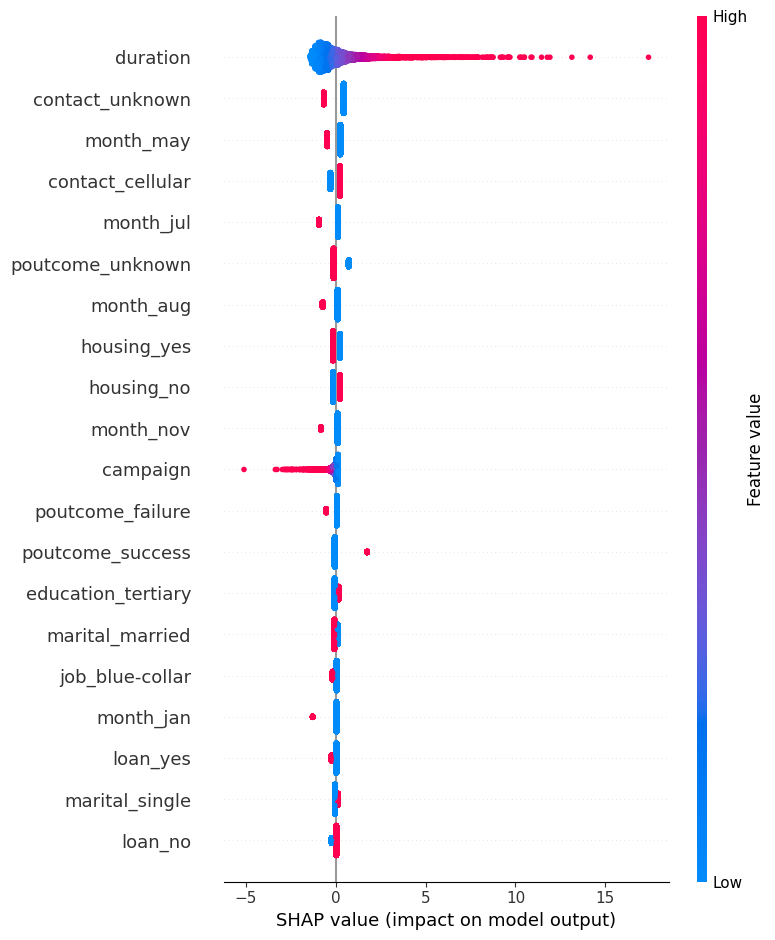

In [101]:
shap_values.feature_names = feature_names
shap.summary_plot(
    shap_values,
    x_test_final,
    feature_names=feature_names
)